# Optimization and resampling

Executable companion to chapter 14.

Chapter 13 left two loose ends: the variational parameters were found by
scanning a grid, and the error bar came from the autocorrelation time.  Both
are fixed here, in the three stages a real calculation has:

1. **Optimise** — the gradient of the energy is another Monte Carlo average,
   so it costs nothing extra.  Short, noisy runs are enough while we are
   locating a minimum.
2. **Produce** — with the parameters fixed, run once with millions of samples.
3. **Resample** — the samples are correlated, so $\sigma/\sqrt N$ is wrong.
   Blocking, bootstrap or jackknife give the honest error.

In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import vmcoptimise as vo
from vmc import TAUT_ENERGY, correlation_time

## 1. The gradient of the energy

Write the energy as a Rayleigh quotient and differentiate.  With
$A=\int \psi\,H\psi$ and $B=\int\psi^2$, so that $E=A/B$,

$$
\partial_\theta B = 2\int \psi\,\partial_\theta\psi ,
\qquad
\partial_\theta A = 2\int (\partial_\theta\psi)\,H\psi ,
$$

the second using the hermiticity of $H$ — which is the one assumption of the
whole derivation, and the reason no derivative of $H\psi$ is ever needed.
Substituting into the quotient rule and using $A=EB$,

$$
\partial_\theta E
= 2\left[\frac{\int(\partial_\theta\psi)H\psi}{\int\psi^2}
- E\,\frac{\int\psi\,\partial_\theta\psi}{\int\psi^2}\right] .
$$

Now multiply and divide the integrands by $\psi^2$.  What is left outside is
$p(x)=\psi^2/\int\psi^2$, the density the Metropolis walk already samples, and
inside are the local energy $E_L=(H\psi)/\psi$ and the **log-derivative**
$O_\theta = (\partial_\theta\psi)/\psi = \partial_\theta\ln\psi$:

$$
\boxed{\;\partial_\theta E
= 2\left(\langle O_\theta E_L\rangle - \langle O_\theta\rangle\langle E_L\rangle\right)
= 2\,\mathrm{Cov}(O_\theta, E_L)\;}
$$

Three integrals — $\langle O_\theta E_L\rangle$, $\langle O_\theta\rangle$ and
$\langle E_L\rangle$ — all with respect to the *same* density, so one random
walk delivers all of them.  It needs only first derivatives of $\ln\psi$, no
derivatives of $E_L$, and no extra sampling.  For a complex $\psi$ the same
derivation gives
$\partial_\theta E = 2\,\Re\left(\langle O_\theta^{*}E_L\rangle
- \langle O_\theta^{*}\rangle\langle E_L\rangle\right)$.

In [2]:
rng = np.random.default_rng(3)
worst = 0.0
for _ in range(40):
    r = rng.normal(0.0, 1.0, (2, 2))
    for a, b in ((0.98, 0.40), (0.80, 0.25), (1.10, 0.60)):
        worst = max(worst, float(np.abs(vo.log_psi_gradient(r, a, b)
                                        - vo.log_psi_gradient_fd(r, a, b)).max()))
print(f"d lnPsi/d(alpha,beta), analytic vs finite differences: {worst:.1e}")

d lnPsi/d(alpha,beta), analytic vs finite differences: 1.7e-09


In [3]:
print(f"{'alpha':>6s} {'beta':>6s} {'dE/da':>19s} {'dE/db':>19s}")
for a, b in ((0.90, 0.30), (1.00, 0.40), (1.05, 0.50)):
    g = vo.sample(a, b, n_cycles=15000, rng=np.random.default_rng(99))["gradient"]
    h, num = 0.01, np.empty(2)
    for k, (da, db) in enumerate(((h, 0.0), (0.0, h))):
        p = vo.sample(a+da, b+db, n_cycles=15000, rng=np.random.default_rng(99))["energy"]
        m = vo.sample(a-da, b-db, n_cycles=15000, rng=np.random.default_rng(99))["energy"]
        num[k] = (p - m)/(2*h)
    print(f"{a:6.2f} {b:6.2f} {g[0]:9.5f} vs {num[0]:7.5f} "
          f"{g[1]:9.5f} vs {num[1]:7.5f}")
print("\nThey agree within the noise — and the analytic route costs one run")
print("instead of four, with no cancellation of nearly equal numbers.")

 alpha   beta               dE/da               dE/db


  0.90   0.30  -0.41045 vs -0.36418  -0.29194 vs -0.24605


  1.00   0.40   0.02894 vs 0.02987   0.01222 vs 0.02174


  1.05   0.50   0.21955 vs 0.21355   0.10397 vs 0.10863

They agree within the noise — and the analytic route costs one run
instead of four, with no cancellation of nearly equal numbers.


## 2. Gradient descent

$\theta \leftarrow \theta - \eta\,\nabla_\theta E$, starting deliberately far
from the minimum.  Note the budget: 6000 cycles per step, far too few to
*report* an energy but ample to decide which way is down.

 iter     alpha      beta       energy      |grad|
    1   0.85000   0.20000     3.109414    1.330032
    2   0.89561   0.24840     3.045335    0.705914
    3   0.92159   0.27229     3.029706    0.507672
    4   0.94097   0.28869     3.015757    0.367980
    5   0.95482   0.30079     3.010026    0.308842
   10   0.99137   0.33306     3.002619    0.098912
   15   1.00313   0.34716     3.001162    0.042637
   20   1.00632   0.35500     3.000192    0.029422

converged to alpha = 1.0067, beta = 0.3564


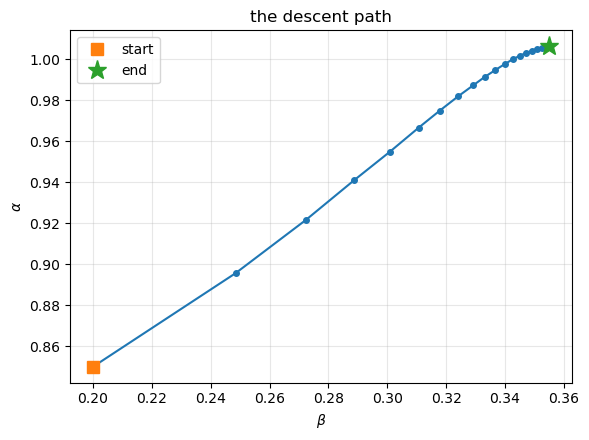

In [4]:
theta, history = vo.gradient_descent(0.85, 0.20, learning_rate=0.05,
                                     max_iter=20, n_cycles=4000)
print(f"{'iter':>5s} {'alpha':>9s} {'beta':>9s} {'energy':>12s} {'|grad|':>11s}")
for it, p, e, g, _ in history:
    if it <= 4 or it % 5 == 0:
        print(f"{it:5d} {p[0]:9.5f} {p[1]:9.5f} {e:12.6f} "
              f"{np.linalg.norm(g):11.6f}")
print(f"\nconverged to alpha = {theta[0]:.4f}, beta = {theta[1]:.4f}")

path = np.array([h[1] for h in history])
plt.figure(figsize=(6, 4.5))
plt.plot(path[:, 1], path[:, 0], "o-", ms=4)
plt.plot(path[0, 1], path[0, 0], "s", ms=9, label="start")
plt.plot(path[-1, 1], path[-1, 0], "*", ms=14, label="end")
plt.xlabel(r"$\beta$"); plt.ylabel(r"$\alpha$")
plt.title("the descent path"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Quasi-Newton methods: the secant condition, Broyden and BFGS

Newton's method for $F(x)=0$ linearises, $J_k s_k = -F(x_k)$, and needs the
$n\times n$ Jacobian at every step.  Quasi-Newton methods never form it.  From
the step and the change in the function,

$$
s_k = x_{k+1}-x_k, \qquad y_k = F(x_{k+1})-F(x_k) \approx J s_k ,
$$

they require the new approximation to reproduce the observed change exactly —
the **secant condition** $B_{k+1}s_k = y_k$ — and fix the remaining $n^2-n$
degrees of freedom by changing as little as possible.

### Broyden: minimum change in the Frobenius norm

$$
\min_{\Delta B}\ \|\Delta B\|_F^2 \quad\text{s.t.}\quad \Delta B\,s = r,
\qquad r = y - B s .
$$

With $\|X\|_F^2 = \mathrm{Tr}(X^TX)$ (chapter 1) the Lagrangian is
$\mathrm{Tr}(\Delta B^T\Delta B) + 2\lambda^T(\Delta B s - r)$, and
$\partial\,\mathrm{Tr}(X^TX)/\partial X = 2X$ gives $\Delta B = -\lambda s^T$ —
**rank one before anything else is imposed**.  The constraint fixes $\lambda$:

$$
\boxed{\;B_{k+1} = B_k + \frac{(y_k - B_k s_k)s_k^T}{s_k^Ts_k}\;}
\qquad
H_{k+1} = H_k + \frac{(s_k - H_k y_k)y_k^T}{y_k^Ty_k}
$$

the second being the same calculation for the inverse, $H_{k+1}y_k = s_k$.

### BFGS: symmetric, positive definite, rank two

For *minimisation* the matrix approximates a Hessian, so it must also be
symmetric and positive definite.  A rank-one update cannot do that; a rank-two
one can.  With $\rho = 1/(y^Ts)$ and $V = I - \rho s y^T$,

$$
\boxed{\;H_{k+1} = V H_k V^T + \rho\, s s^T\;}
\qquad
B_{k+1} = B_k - \frac{B_k s s^T B_k}{s^T B_k s} + \frac{y y^T}{y^T s}
$$

Symmetry is manifest.  $V^Ty = y - \rho y(s^Ty) = 0$ gives the secant property
$H_{+}y = s$ in one line.  And
$z^TH_{+}z = (V^Tz)^TH(V^Tz) + \rho(s^Tz)^2 > 0$ provided $H\succ0$ and
$\rho>0$, i.e. provided the **curvature condition** $s^Ty>0$ holds — which is
exactly what the second Wolfe condition of the line search enforces.  *The
line search is not a convenience; it is what keeps the curvature model well
posed.*  Remember that when we come to the Monte Carlo case.

In [5]:
checks = vo.check_quasi_newton_algebra(n=5, n_trials=200)
labels = (("frobenius",      "||A||_F^2 - Tr(A^T A)"),
          ("vectorisation",  "vec(A).vec(B) - Tr(A^T B)"),
          ("broyden_secant", "Broyden:  |B_new s - y|"),
          ("broyden_minimal","Broyden:  minimality margin (must be >= 0)"),
          ("bfgs_secant",    "BFGS:     |H_new y - s|"),
          ("bfgs_symmetry",  "BFGS:     |H_new - H_new^T|"),
          ("bfgs_inverse",   "BFGS:     |B_new H_new - I|"),
          ("dfp_secant",     "DFP:      |H_new y - s|"))
for key, label in labels:
    print(f"{label:<44s} {checks[key]:.2e}")
print(f"{'BFGS: smallest eigenvalue of H_new':<44s} "
      f"{checks['bfgs_smallest_eigenvalue']:.2e}")

||A||_F^2 - Tr(A^T A)                        1.07e-14
vec(A).vec(B) - Tr(A^T B)                    3.55e-15
Broyden:  |B_new s - y|                      1.78e-15
Broyden:  minimality margin (must be >= 0)   5.03e-01
BFGS:     |H_new y - s|                      3.74e-10
BFGS:     |H_new - H_new^T|                  2.33e-10
BFGS:     |B_new H_new - I|                  5.55e-08
DFP:      |H_new y - s|                      5.17e-14
BFGS: smallest eigenvalue of H_new           1.82e-03


The minimality line deserves a word.  For each Broyden update the check builds
random competitors

$$
\Delta B' = \Delta B + Z\left(I - \frac{s s^T}{s^Ts}\right),
$$

which satisfy the same secant condition because the projector annihilates $s$,
and confirms that none of them is closer to $B_k$.  The two pieces are
orthogonal in the Frobenius inner product, so this is just Pythagoras — and it
is *why* the answer had to be rank one.

### Broyden against Newton on a nonlinear system

$F(x,y) = (x^2+y^2-4,\ e^x+y-1)$, from $(1,2)$.  Newton uses the analytic
Jacobian; Broyden starts from $H_0 = I$ and uses none.

In [6]:
F = lambda v: np.array([v[0]**2 + v[1]**2 - 4.0, math.exp(v[0]) + v[1] - 1.0])
J = lambda v: np.array([[2*v[0], 2*v[1]], [math.exp(v[0]), 1.0]])

_, hn = vo.newton_root(F, J, [1.0, 2.0])
_, hb = vo.broyden_root(F, [1.0, 2.0])
print(f"{'iter':>5s} {'|F| Newton':>13s} {'|F| Broyden':>13s}")
for k in range(max(len(hn), len(hb))):
    a = f"{hn[k][2]:13.3e}" if k < len(hn) else " " * 13
    b = f"{hb[k][2]:13.3e}" if k < len(hb) else " " * 13
    print(f"{k:5d} {a} {b}")
print(f"\nNewton: {len(hn)-1} iterations and {len(hn)-1} Jacobians.")
print(f"Broyden: {len(hb)-1} iterations and no Jacobian at all.")

 iter    |F| Newton   |F| Broyden
    0     3.850e+00     3.850e+00
    1     3.443e+00     2.012e+00
    2     4.891e+00     3.207e+00
    3     7.506e-01     2.655e+00
    4     3.093e-02     9.564e-01
    5     5.919e-05     1.411e-01
    6     2.185e-10     5.739e-02
    7     0.000e+00     5.752e-03
    8                   4.092e-04
    9                   4.006e-06
   10                   6.036e-09
   11                   3.105e-11

Newton: 7 iterations and 7 Jacobians.
Broyden: 11 iterations and no Jacobian at all.


## 4. Why curvature matters

For a quadratic $f = \tfrac12 x^TAx - b^Tx$, steepest descent with the optimal
step obeys

$$
\|e_{k+1}\| \le \frac{\kappa-1}{\kappa+1}\|e_k\|,
\qquad \kappa = \lambda_{\max}/\lambda_{\min},
$$

so the iteration count grows **linearly with the condition number** even when
the step length is chosen perfectly at every step.  That is not a defect of
the step size; it is a defect of the direction.  The gradient alone cannot
tell a narrow valley from a round bowl.

In [7]:
print(f"{'kappa':>8s} {'steepest':>10s} {'BFGS':>7s} {'DFP':>7s} "
      f"{'Broyden':>9s} {'Powell':>8s}")
rows = []
for kappa in (1.0, 10.0, 100.0, 1000.0):
    n = 6
    diag = np.logspace(0.0, math.log10(kappa), n)
    b = np.ones(n)
    f = lambda x, d=diag, b=b: 0.5 * float(x @ (d * x)) - float(b @ x)
    g = lambda x, d=diag, b=b: d * x - b
    x0 = np.zeros(n)
    counts = [len(vo.bfgs_minimise(f, g, x0, tol=1e-6, update=u,
                                   max_iter=2000)[1]) - 1
              for u in ("bfgs", "dfp", "broyden")]
    sd = len(vo.steepest_descent_minimise(f, g, x0, tol=1e-6)[1]) - 1
    pw = len(vo.powell_minimise(f, x0, tol=1e-12)[1]) - 1
    rows.append((kappa, sd, *counts, pw))
    print(f"{kappa:8.0f} {sd:10d} {counts[0]:7d} {counts[1]:7d} "
          f"{counts[2]:9d} {pw:8d}")

   kappa   steepest    BFGS     DFP   Broyden   Powell
       1          1       1       1         1        2
      10         68      11      10        24        2
     100        600       9      11        68        2
    1000       5244      10       9      1478        5


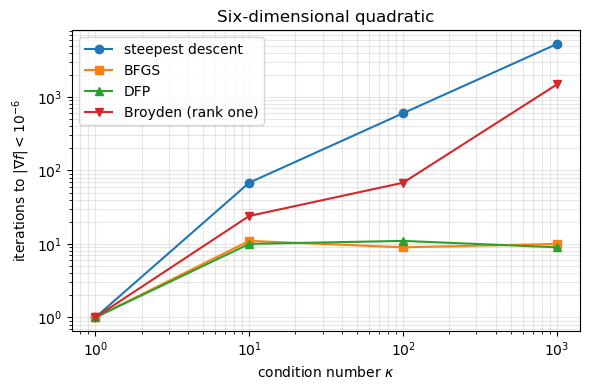

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
kappas = [r[0] for r in rows]
for column, label, style in ((1, "steepest descent", "o-"),
                             (2, "BFGS", "s-"),
                             (3, "DFP", "^-"),
                             (4, "Broyden (rank one)", "v-")):
    ax.loglog(kappas, [r[column] for r in rows], style, label=label)
ax.set_xlabel(r"condition number $\kappa$")
ax.set_ylabel("iterations to $|\\nabla f| < 10^{-6}$")
ax.set_title("Six-dimensional quadratic")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The two rank-two updates are flat: about ten iterations whether the problem is
round or stretched by a factor of a thousand.  That is what "learning the
curvature" means in practice.  Broyden's rank-one update satisfies the secant
condition but neither symmetry nor positive definiteness, and as a *minimiser*
it degrades — it is a root finder being used for the wrong job.

Rosenbrock's banana, which is not quadratic and has a curved valley, makes the
same point more brutally.

BFGS          35 iterations   f = 4.251e-21
steepest   19376 iterations   f = 7.583e-17
Powell       500 cycles       f = 2.174e-14


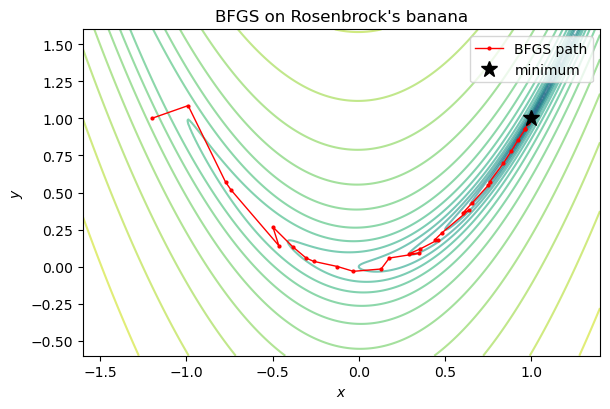

In [9]:
rosen = lambda v: (1.0 - v[0])**2 + 100.0 * (v[1] - v[0]**2)**2
rosen_grad = lambda v: np.array([
    -2.0 * (1.0 - v[0]) - 400.0 * v[0] * (v[1] - v[0]**2),
    200.0 * (v[1] - v[0]**2)])

xb, hist_b = vo.bfgs_minimise(rosen, rosen_grad, [-1.2, 1.0], tol=1e-8)
xs, hist_s = vo.steepest_descent_minimise(rosen, rosen_grad, [-1.2, 1.0],
                                          tol=1e-8)
xp, hist_p = vo.powell_minimise(rosen, [-1.2, 1.0], tol=1e-12, max_iter=500)
print(f"BFGS      {len(hist_b)-1:6d} iterations   f = {hist_b[-1][2]:.3e}")
print(f"steepest  {len(hist_s)-1:6d} iterations   f = {hist_s[-1][2]:.3e}")
print(f"Powell    {len(hist_p)-1:6d} cycles       f = {hist_p[-1][2]:.3e}")

path = np.array([h[1] for h in hist_b])
gx, gy = np.meshgrid(np.linspace(-1.6, 1.4, 300), np.linspace(-0.6, 1.6, 300))
gz = (1 - gx)**2 + 100 * (gy - gx**2)**2
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.contour(gx, gy, np.log10(gz + 1e-12), levels=25, cmap="viridis", alpha=0.6)
ax.plot(path[:, 0], path[:, 1], "r.-", lw=1, ms=4, label="BFGS path")
ax.plot(1, 1, "k*", ms=12, label="minimum")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("BFGS on Rosenbrock's banana")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Derivative-free optimisation: Powell's method

Sometimes there is no gradient — a black-box simulation, or one so noisy that
a finite difference is meaningless.  Powell's method reduces the problem to a
sequence of **line minimisations**,

$$
\phi(\alpha) = f(x + \alpha d), \qquad \alpha^{*} = \arg\min_\alpha \phi(\alpha),
$$

solved by golden-section search: keeping the interior points at
$1 - 1/\varphi = 0.381966\ldots$ makes the surviving bracket self-similar, so
one point is reused and each iteration costs a single function evaluation
while shrinking the bracket by $0.618$.

Why choose the directions carefully?  On a quadratic, having minimised along
$d_i$ we have $d_i^T\nabla f = 0$; moving along $d_j$ changes the gradient by
$Ad_j$ times the step, so the first minimisation survives if and only if

$$
d_i^T A\, d_j = 0 ,
$$

the **conjugacy** condition of the conjugate gradient method.  Powell's
insight is that conjugate directions can be *generated* from function values:
minimise along each direction in turn, form the net displacement of the whole
cycle $d_{\rm new} = x_n - x_0$, and substitute it for the direction that
helped most.  On a quadratic the directions become conjugate and the method
terminates in $n$ cycles — which is the last column of the table above.

In [10]:
# Golden section on a one-dimensional slice
phi = lambda a: (a - 0.7)**2 + 0.3 * np.sin(6 * a)
grid = np.linspace(0.0, 1.5, 20001)
print(f"golden section: {vo.golden_section(phi, 0.0, 1.5, tol=1e-10):.8f}")
print(f"fine grid:      {grid[np.argmin([phi(a) for a in grid])]:.8f}")
print("(golden section assumes phi is unimodal on the bracket; this phi has")
print(" several minima, so the bracket must be chosen with some care.)")
print()

# Powell's direction set on a badly scaled quadratic, cycle by cycle
diag = np.array([1.0, 1000.0])
f2 = lambda x: 0.5 * float(x @ (diag * x)) - float(np.ones(2) @ x)
xp, hp = vo.powell_minimise(f2, [-2.0, 2.0], tol=1e-10)
for it, x, fx, evals in hp[:6]:
    print(f"cycle {it}:  x = ({x[0]:9.5f}, {x[1]:9.6f})   f = {fx:12.8f}   "
          f"{evals} line minimisations")
print(f"\nexact minimum: x = (1, 0.001), f = {f2(1.0/diag):.8f}")
print(f"converged in {len(hp)-1} cycles with no derivatives at all")

golden section: 0.77204265
fine grid:      0.77205000
(golden section assumes phi is unimodal on the bracket; this phi has
 several minima, so the bracket must be chosen with some care.)

cycle 0:  x = ( -2.00000,  2.000000)   f = 2002.00000000   0 line minimisations
cycle 1:  x = (  0.00100,  0.000000)   f =  -0.00099959   2 line minimisations
cycle 2:  x = (  1.00000,  0.001000)   f =  -0.50050000   4 line minimisations
cycle 3:  x = (  1.00000,  0.001000)   f =  -0.50050000   6 line minimisations

exact minimum: x = (1, 0.001), f = -0.50050000
converged in 3 cycles with no derivatives at all


Two warnings.  A line minimisation locates the minimum of $\phi$ only to
$O(\sqrt{\epsilon_{\rm mach}})$ in $\alpha$, because $\phi$ is quadratic there
and a quadratic is flat at its minimum.  And if $f$ is *noisy*, golden section
will happily converge on a fluctuation.  Both objections apply with full force
to variational Monte Carlo.

## 6. Stochastic reconfiguration

SR comes from a different direction entirely: not from approximating the
Hessian of the energy, but from asking what imaginary-time evolution would do
and doing as much of it as the variational manifold permits.

**Imaginary time.**  $|\Psi(\tau)\rangle = e^{-\tau H}|\Psi(0)\rangle =
\sum_n c_n e^{-\tau E_n}|n\rangle \to c_0e^{-\tau E_0}|0\rangle$: every
excited component is filtered out.  We cannot follow it, because
$(1-\delta\tau H)|\Psi(\alpha)\rangle$ does not lie on the manifold
$\mathcal{M} = \{|\Psi(\alpha)\rangle\}$.  So take the step and **project
back**.

**The step.**  Use the shifted form
$|\Psi'_{\rm exact}\rangle = [1-\delta\tau(H-E)]|\Psi\rangle$.  Since
$\langle\Psi|(H-E)|\Psi\rangle = 0$, this moves the state *across* the ray it
lies on rather than along it — it changes the physics, not the norm.

**The projection.**  Expand the variational side in the tangent vectors
$|\Psi_k\rangle = \partial_{\alpha_k}|\Psi\rangle$ and minimise the mismatch

$$
\mathcal{D} = \langle\Delta|\Delta\rangle,
\qquad
|\Delta\rangle = \sum_k\delta\alpha_k|\Psi_k\rangle + \delta\tau(H-E)|\Psi\rangle .
$$

$\mathcal{D}$ is quadratic in $\delta\alpha$, so stationarity is a linear
system.  Written with the normalised state (to remove the redundant component
along $|\Psi\rangle$) and turned into Monte Carlo averages over
$P(x) = |\Psi(x)|^2/\langle\Psi|\Psi\rangle$, it becomes

$$
\boxed{\;S\,\delta\alpha = -\delta\tau\, g\;}
\qquad
S_{ij} = \langle O_iO_j\rangle - \langle O_i\rangle\langle O_j\rangle,
\qquad
g_i = \langle O_iE_L\rangle - \langle O_i\rangle\langle E_L\rangle
= \tfrac12\partial_{\alpha_i}E .
$$

**Two readings.**  $S$ is the covariance of the log-derivatives, hence
symmetric and positive *semi*definite, and singular exactly when the
parameters are locally redundant.  It is also the metric of the manifold:
$ds^2 = \sum_{ij}S_{ij}d\alpha_id\alpha_j$ is the squared distance between
nearby normalised states — the quantum geometric tensor, four times the
quantum Fisher information.  Steepest descent in *that* metric is
$\delta\alpha \propto -S^{-1}g$, Amari's **natural gradient**.  Two
derivations, one from imaginary-time projection and one from Riemannian
geometry, giving the same update.

In [11]:
sr_report = vo.sr_metric_report(1.00, 0.40, n_cycles=40000)
S = sr_report["metric"]
print("S =")
print(S)
print(f"\neigenvalues       {sr_report['eigenvalues']}")
print(f"condition number  {sr_report['condition']:.1f}")
print(f"gradient          {sr_report['gradient']}")
print()
print(f"{'lambda':>10s} {'|(S+lI)^-1 g|':>15s} {'angle to g (deg)':>18s}")
for lam, length, angle in sr_report["regularisation"]:
    print(f"{lam:10.0e} {length:15.5f} {angle:18.2f}")

S =
[[0.64780165 0.28617337]
 [0.28617337 0.22599836]]

eigenvalues       [0.08140781 0.7923922 ]
condition number  9.7
gradient          [0.02954761 0.01285379]

    lambda   |(S+lI)^-1 g|   angle to g (deg)
     1e-06         0.04654              25.97
     1e-04         0.04652              25.95
     1e-03         0.04636              25.71
     1e-02         0.04492              23.52
     1e-01         0.03747              12.52
     1e+00         0.01803               2.16
     1e+01         0.00299               0.23


$S$ is positive semidefinite, and in a Monte Carlo estimate its *small*
eigenvalues are the ones dominated by noise.  Inverting it as it stands
amplifies that noise without limit, so one shifts,

$$
(S + \varepsilon I)\,\delta\alpha = -\delta\tau\, g ,
$$

which is Tikhonov regularisation and interpolates: at $\varepsilon\to0$ the
natural gradient, at $\varepsilon\to\infty$ plain steepest descent with
learning rate $\eta/\varepsilon$.  The table shows the crossover — the step
shortens and rotates back towards the bare gradient.  Even with two parameters
chosen by hand to do different things, the natural-gradient direction sits
$26^{\circ}$ away from the gradient.

For large $p$ one never forms $S$: $Sv = \langle O(O\cdot v)\rangle -
\langle O\rangle\langle O\cdot v\rangle$ costs one pass over the samples, and
the system is solved by conjugate gradients.  That is what makes SR practical
for neural-network wave functions with millions of parameters.

## 7. The methods compared on the quantum dot

Same start, same budget per step.  The last two rows are the informative ones.

In [12]:
print(f"{'method':>30s} {'steps':>6s} {'alpha':>9s} {'beta':>9s} "
      f"{'final E':>12s}")
for name, routine, kw in (
        ("gradient descent", vo.gradient_descent, dict(learning_rate=0.05)),
        ("with momentum", vo.momentum_descent,
         dict(learning_rate=0.03, momentum=0.6)),
        ("stochastic reconfiguration", vo.stochastic_reconfiguration,
         dict(learning_rate=0.2))):
    th, h = routine(0.85, 0.20, max_iter=15, n_cycles=4000, **kw)
    print(f"{name:>30s} {len(h):6d} {th[0]:9.5f} {th[1]:9.5f} {h[-1][2]:12.6f}")

th, h, skipped = vo.bfgs_descent(0.85, 0.20, max_iter=15, n_cycles=4000)
print(f"{'BFGS, damped + trust radius':>30s} {len(h):6d} {th[0]:9.5f} "
      f"{th[1]:9.5f} {h[-1][2]:12.6f}")
th2, h2, skipped2 = vo.bfgs_descent(0.85, 0.20, max_iter=15, n_cycles=4000,
                                    damping=False, trust_radius=np.inf)
print(f"{'BFGS, no safeguards':>30s} {len(h2):6d} {th2[0]:9.5f} "
      f"{th2[1]:9.5f} {h2[-1][2]:12.6f}")
th3, h3, calls = vo.powell_vmc(0.85, 0.20, n_cycles=4000, max_iter=3)
print(f"{'Powell, derivative free':>30s} {len(h3)-1:6d} {th3[0]:9.5f} "
      f"{th3[1]:9.5f} {h3[-1][2]:12.6f}")
print()
print(f"BFGS rejected the curvature condition {skipped} times with the")
print(f"safeguards and {skipped2} times without; Powell used {calls} energy")
print("evaluations against 15 gradient evaluations, each of which also")
print("delivered the energy.")

                        method  steps     alpha      beta      final E


              gradient descent     15   1.00411   0.34905     3.001162


                 with momentum     15   1.00817   0.37283     3.000559


    stochastic reconfiguration     15   0.98820   0.39787     3.000394


   BFGS, damped + trust radius     15   0.98807   0.39872     3.000381


           BFGS, no safeguards     15   1.24115 271.08137     3.473468


       Powell, derivative free      3   1.00554   0.36432     3.001191

BFGS rejected the curvature condition 0 times with the
safeguards and 7 times without; Powell used 100 energy
evaluations against 15 gradient evaluations, each of which also
delivered the energy.


Run BFGS on a Monte Carlo gradient the way one would run it on a
deterministic function — no trust radius, no damped update — and it leaves the
physical region.  The reason is the one anticipated above: curvature is
inferred from *differences* of gradients, and near the minimum, where the true
difference is small, that difference is pure noise.  The curvature condition
$s^Ty>0$ then fails, and the ordinary repair, a line search, is unavailable
because we cannot reliably test whether the energy has decreased.

Powell's method needs no gradient and does converge, but it spends an order of
magnitude more energy evaluations to do it, and its line minimisations resolve
fluctuations rather than curvature.

**For two parameters the choice hardly matters.**  The reason to set them up
carefully is what comes later: thousands of parameters, no grid conceivable, a
non-convex surface, a stochastic gradient, and no line search.  Of everything
in this notebook, only a first-order update on the covariance gradient and
stochastic reconfiguration survive that list.

## 8. The production run

Nothing left to decide, only statistics to accumulate — and that parallelises
perfectly, since the walkers are independent.

In [13]:
run = vo.production_run(1.00, 0.40, n_walkers=1000, n_steps=2000,
                        time_step=0.5, rng=np.random.default_rng(2024))
series = run["series"]
print(f"{run['n_walkers']} walkers x {run['n_steps']} steps "
      f"= {run['total_samples']:,} local-energy evaluations")
print(f"acceptance {run['acceptance']:.1%}, mean {series.mean():.8f}")
print(f"correlation time of the walker-averaged series "
      f"{correlation_time(series):.2f}")
print("\nAveraging over independent walkers divides the variance and the")
print("autocovariance by the same factor, so tau is unchanged — the error")
print("analysis of chapter 12 is still needed.")

1000 walkers x 2000 steps = 2,000,000 local-energy evaluations
acceptance 87.1%, mean 3.00054858
correlation time of the walker-averaged series 1.27

Averaging over independent walkers divides the variance and the
autocovariance by the same factor, so tau is unchanged — the error
analysis of chapter 12 is still needed.


## 9. The exact variance of a correlated mean

The sample mean is a **linear** functional of the data, $\bar X = \bm{1}^T\bm{X}/N$,
and for any deterministic $\bm{a}$, $\mathrm{Var}(\bm{a}^T\bm{X}) = \bm{a}^T\Sigma\bm{a}$
with $\Sigma_{ij} = \mathrm{Cov}(X_i,X_j)$.  So, with no approximation at all,

$$
\boxed{\;\mathrm{Var}(\bar X) = \frac{1}{N^2}\bm{1}^T\Sigma\,\bm{1}
= \frac{1}{N^2}\sum_{i,j}\mathrm{Cov}(X_i,X_j)\;}
$$

That is the whole problem in one line.  The familiar $\sigma^2/N$ is what this
becomes when $\Sigma$ is diagonal, and a Markov chain never gives a diagonal
$\Sigma$.

**Stationarity.**  After equilibration the chain is weakly stationary:
$\langle X_i\rangle=\mu$ and $\mathrm{Cov}(X_i,X_j)=C(|i-j|)$ depends only on the
lag.  Then $\Sigma$ is **Toeplitz**, constant along its diagonals, and the $N^2$
unknown entries collapse to $N$ unknown functions $C(t)$.

**Collecting by lag.**  The lag $t=0$ occurs $N$ times in the $N\times N$ array
and each $t\ge1$ occurs $2(N-t)$ times, so

$$
\mathrm{Var}(\bar X) = \frac{C(0)}{N} + \frac{2}{N^2}\sum_{t=1}^{N-1}(N-t)C(t)
= \frac{\sigma^2}{N}\left[1 + 2\sum_{t=1}^{N-1}\left(1-\frac{t}{N}\right)\rho(t)\right],
$$

**exact** for a stationary series of finite length, with $\rho(t)=C(t)/C(0)$.
The triangular weight $1-t/N$ says that long lags are simply less represented
in a finite sample.  Dropping it gives the large-$N$ result of chapter 12,

$$
\mathrm{Var}(\bar X)\approx\frac{\sigma^2}{N}\tau,
\qquad \tau = 1 + 2\sum_{t\ge1}\rho(t),
\qquad N_{\rm eff} = \frac{N}{\tau}.
$$

**A warning about conventions.**  Much of the lattice literature uses
$\tau_{\rm int} = \tfrac12 + \sum_t\rho(t) = \tau/2$ and writes
$\mathrm{Var} = 2\tau_{\rm int}\sigma^2/N$.  Same statement, factor of two in the
bookkeeping.  Check which one a paper or a code means before comparing numbers.

In [14]:
exact = vo.variance_of_mean_exact(series, rule="first-negative")
sokal = vo.variance_of_mean_exact(series, rule="sokal")

print(f"naive sqrt(sigma^2/N)                  "
      f"{math.sqrt(exact['naive']):.8f}")
print(f"lag sum, weight (1-t/N), W = {exact['window']:<3d}      "
      f"{math.sqrt(exact['lag_sum']):.8f}")
print(f"large-N limit (sigma^2/N) tau          "
      f"{math.sqrt(exact['large_n']):.8f}")
print(f"same, Sokal's window W = {sokal['window']:<3d}          "
      f"{math.sqrt(sokal['lag_sum']):.8f}")
print(f"(1/N^2) 1^T Sigma 1, EVERY lag         "
      f"{math.sqrt(exact['quadratic_form']):.8f}   <-- nonsense")
print()
print(f"tau     = {exact['tau']:.4f}")
print(f"tau_int = {exact['tau_int']:.4f}")
print(f"N_eff   = {exact['n_eff']:.1f} out of {len(series)}")

naive sqrt(sigma^2/N)                  0.00003276
lag sum, weight (1-t/N), W = 2        0.00003689
large-N limit (sigma^2/N) tau          0.00003689
same, Sokal's window W = 4            0.00003639
(1/N^2) 1^T Sigma 1, EVERY lag         0.00001850   <-- nonsense

tau     = 1.2687
tau_int = 0.6343
N_eff   = 1576.5 out of 2000


The last line of that output is the point of this section.  The formula is
exact, and evaluating it as written gives an answer **smaller than the naive
one**, with $\tau\to0$.

The reason is that we do not know $C(t)$, we estimate it, and each
$\hat C(t)$ carries an error of order $\sigma^2/\sqrt N$ that does *not* shrink
as $t$ grows.  Adding $N$ of them accumulates an error of order
$\sigma^2\sqrt N$ against a signal of order $\sigma^2\tau$.  So one truncates
the sum at some window $W$ — and the answer depends on where.

  window W       tau          error
         1     1.228     0.00003630
         2     1.269     0.00003689
         5     1.226     0.00003626
        10     1.175     0.00003550
        20     1.367     0.00003828


        50     1.384     0.00003849
       100     1.420     0.00003895


       500     1.158     0.00003535


      1999    -0.000     0.00001850


  blocking        --     0.00004858   (1 transformations, no free parameter)


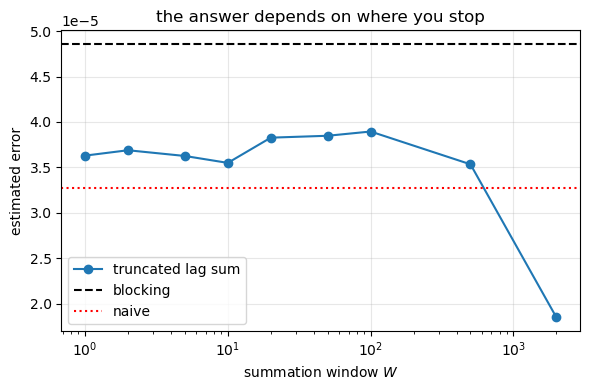

In [15]:
print(f"{'window W':>10s} {'tau':>9s} {'error':>14s}")
windows, errors = [], []
for W in (1, 2, 5, 10, 20, 50, 100, 500, len(series) - 1):
    e = vo.variance_of_mean_exact(series, window=W)
    err = math.sqrt(max(e["lag_sum"], 0.0))
    windows.append(W); errors.append(err)
    print(f"{W:10d} {e['tau']:9.3f} {err:14.8f}")
_, blocked, k = vo.blocking(series)
print(f"{'blocking':>10s} {'--':>9s} {blocked:14.8f}   "
      f"({k} transformations, no free parameter)")

plt.figure(figsize=(6, 4))
plt.semilogx(windows, errors, "o-", label="truncated lag sum")
plt.axhline(blocked, ls="--", color="k", label="blocking")
plt.axhline(series.std(ddof=1)/math.sqrt(len(series)), ls=":", color="r",
            label="naive")
plt.xlabel("summation window $W$"); plt.ylabel("estimated error")
plt.title("the answer depends on where you stop")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Between $W=1$ and $W=500$ the error wanders by ten per cent, and at $W=N-1$ it
collapses.  **This is the argument for blocking**: the autocorrelation route
needs a decision that changes the answer by more than the answer's own
precision, and offers no principle for making it.

## 10. Blocking, and what it does to $\Sigma$

$$
X_i^{(k+1)} = \tfrac12\left(X_{2i-1}^{(k)}+X_{2i}^{(k)}\right),
\qquad N_k = N/2^k .
$$

Blocking is a linear coarse-graining, so $\Sigma^{(k)}$ is again Toeplitz, and
each step moves weight from the off-diagonals onto the diagonal.  Once the
blocks are longer than the correlation time,

$$
\Sigma^{(k)}\approx s_k^2 I ,
$$

the exact formula collapses to the independent-sample $s_k^2/N_k$, and the
estimate stops rising.  That plateau is the whole method.  Watch it happen on
the badly tuned run, where there is something to see.

  k     N_k        s_k^2   rho(1)   rho(2)   rho(3)  sqrt(s_k^2/N_k)
  0    4000    4.561e-06   0.8242   0.6869   0.5801       0.00003377
  1    2000    4.169e-06   0.7589   0.5402   0.3979       0.00004566
  2    1000    3.683e-06   0.6310   0.3473   0.2211       0.00006069
  3     500    3.023e-06   0.4635   0.1912   0.1267       0.00007776
  4     250    2.166e-06   0.3517   0.0593  -0.0235       0.00009309
  5     125    1.519e-06   0.1573   0.0041   0.0391       0.00011023
  6      62    9.190e-07   0.0869  -0.1125   0.0539       0.00012175


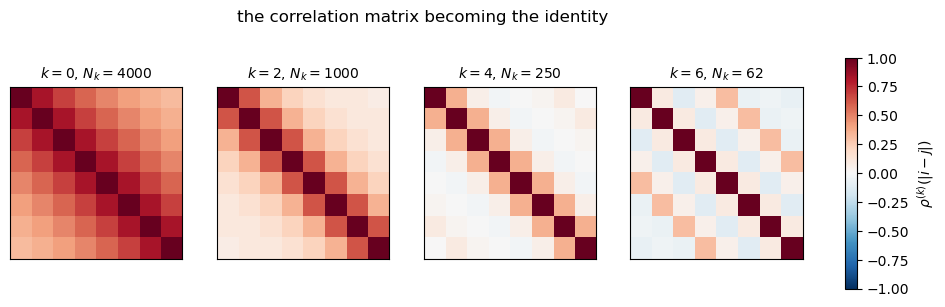

In [16]:
bad = vo.production_run(1.00, 0.40, n_walkers=400, n_steps=4000,
                        time_step=0.02, rng=np.random.default_rng(2024))

print(f"{'k':>3s} {'N_k':>7s} {'s_k^2':>12s} {'rho(1)':>8s} {'rho(2)':>8s} "
      f"{'rho(3)':>8s} {'sqrt(s_k^2/N_k)':>16s}")
levels = vo.blocked_covariance(bad["series"], levels=6)
for k, nk, var_k, rho in levels:
    print(f"{k:3d} {nk:7d} {var_k:12.3e} {rho[0,1]:8.4f} {rho[0,2]:8.4f} "
          f"{rho[0,3]:8.4f} {math.sqrt(var_k/nk):16.8f}")

fig, axes = plt.subplots(1, 4, figsize=(11, 3.0))
for ax, (k, nk, var_k, rho) in zip(axes, levels[::2]):
    im = ax.imshow(rho, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"$k={k}$, $N_k={nk}$", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.02, label=r"$\rho^{(k)}(|i-j|)$")
fig.suptitle("the correlation matrix becoming the identity", y=1.04)
plt.show()

### The three estimators side by side

Blocking with Jonsson's stopping rule, the block bootstrap and the block
jackknife, on the well-tuned run and on the badly tuned one.  The plateau of
the blocking curve below is the same plateau as the last column of the table
above, plotted rather than tabulated.


In [17]:
def report(x, label):
    naive = x.std(ddof=1)/math.sqrt(len(x))
    tau = correlation_time(x)
    _, eb, k = vo.blocking(x)
    _, ebo, bb = vo.bootstrap(x, n_resamples=1000, rng=np.random.default_rng(7))
    _, ej, bj = vo.jackknife(x)
    print(f"{label}")
    print(f"   correlation time tau        {tau:8.2f}")
    print(f"   naive sigma/sqrt(N)         {naive:.8f}")
    print(f"   sqrt(tau) x naive           {naive*math.sqrt(tau):.8f}")
    print(f"   blocking                    {eb:.8f}  ({k} transformations)")
    print(f"   bootstrap, blocks of {bb:<4d}   {ebo:.8f}")
    print(f"   jackknife, blocks of {bj:<4d}   {ej:.8f}")
    print(f"   resampled / naive           {eb/naive:8.2f}")
    return eb

error = report(series, "well tuned, time step 0.5:")
print()
# `bad` is the badly tuned run built in the previous cell
report(bad["series"], "badly tuned, time step 0.02:")
print()
print("With good sampling the naive estimate is only modestly wrong — but")
print("there is no way to know that without measuring.  With bad sampling it")
print("is wrong by a factor of four, silently.")

well tuned, time step 0.5:
   correlation time tau            1.27
   naive sigma/sqrt(N)         0.00003276
   sqrt(tau) x naive           0.00003690
   blocking                    0.00004858  (1 transformations)
   bootstrap, blocks of 2      0.00003486
   jackknife, blocks of 2      0.00003478
   resampled / naive               1.48

badly tuned, time step 0.02:
   correlation time tau           13.95
   naive sigma/sqrt(N)         0.00003377
   sqrt(tau) x naive           0.00012614
   blocking                    0.00015405  (5 transformations)
   bootstrap, blocks of 27     0.00010611
   jackknife, blocks of 27     0.00010427
   resampled / naive               4.56

With good sampling the naive estimate is only modestly wrong — but
there is no way to know that without measuring.  With bad sampling it
is wrong by a factor of four, silently.


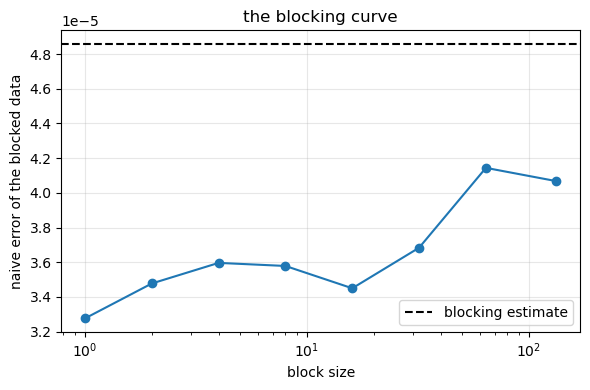

In [18]:
curve = vo.blocking_curve(series)
plt.figure(figsize=(6, 4))
plt.semilogx([len(series)//n for n, _ in curve], [e for _, e in curve], "o-")
plt.axhline(error, ls="--", color="k", label="blocking estimate")
plt.xlabel("block size"); plt.ylabel("naive error of the blocked data")
plt.title("the blocking curve"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. The bootstrap, properly

Suppose the data come from an unknown $F$ and we want the sampling
distribution of some estimator $\hat\theta = f(X_1,\dots,X_N)$.  If we knew
$F$ we would simply repeat the experiment.  We do not — but we have the
**empirical distribution**

$$
\hat F_N(x) = \frac{1}{N}\sum_{i=1}^N \delta(x - X_i),
$$

which converges to $F$ by Glivenko–Cantelli.  The **plug-in principle** says:
do exactly what you would have done with $F$, using $\hat F_N$ instead.
Sampling from $\hat F_N$ *is* resampling with replacement.

For $b = 1,\dots,B$ draw $X_1^*,\dots,X_N^*$ and compute $\hat\theta_b^*$.
Then

$$
\sigma_{\rm boot}^2 = \frac{1}{B-1}\sum_b (\hat\theta_b^* - \bar\theta^*)^2,
\qquad
\widehat{\rm Bias} = \bar\theta^* - \hat\theta,
$$

and the **percentile interval** at confidence $1-\alpha$ is just the
$\alpha/2$ and $1-\alpha/2$ quantiles of the replicates — no normality assumed
anywhere.  The justification is that $\sqrt N(\hat\theta^*-\hat\theta)$, under
resampling with the data held fixed, has the same limiting distribution as
$\sqrt N(\hat\theta-\theta)$ does under repetition of the experiment.

**One assumption, which Monte Carlo data violate**: resampling single points
assumes the points are exchangeable.  They are not.  Resample *blocks*.

200,000 local energies, tau = 1.25, 200 blocks of 1000
each block is 799 correlation times long



E                  3.000569
bootstrap error    0.000105
95% percentile     [3.000373, 3.000773]
+/- 1.96 sigma     [3.000362, 3.000775]


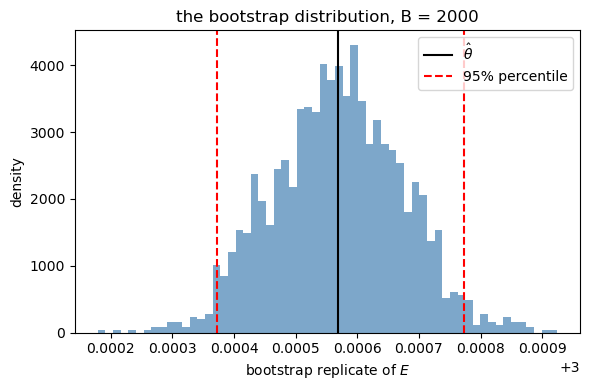

skewness of the replicates +0.013  (Gaussian, so the two intervals agree)


In [19]:
chain = vo.sample(1.00, 0.40, n_cycles=200000, time_step=0.5,
                  rng=np.random.default_rng(31), keep_samples=True)
e_local = chain["samples"]
tau_chain = correlation_time(e_local)
n_blocks = 200
block = len(e_local) // n_blocks
print(f"{len(e_local):,} local energies, tau = {tau_chain:.2f}, "
      f"{n_blocks} blocks of {block}")
print(f"each block is {block/tau_chain:.0f} correlation times long")

boot = vo.block_bootstrap(e_local, n_resamples=2000, n_blocks=n_blocks,
                          rng=np.random.default_rng(5))
low, high = boot["interval"]
print(f"\nE                  {boot['estimate']:.6f}")
print(f"bootstrap error    {boot['error']:.6f}")
print(f"95% percentile     [{low:.6f}, {high:.6f}]")
print(f"+/- 1.96 sigma     [{boot['estimate']-1.96*boot['error']:.6f}, "
      f"{boot['estimate']+1.96*boot['error']:.6f}]")

r = boot["samples"]
plt.figure(figsize=(6, 4))
plt.hist(r, bins=60, density=True, alpha=0.7, color="steelblue")
plt.axvline(boot["estimate"], color="k", label=r"$\hat\theta$")
plt.axvline(low, color="r", ls="--", label="95% percentile")
plt.axvline(high, color="r", ls="--")
plt.xlabel("bootstrap replicate of $E$"); plt.ylabel("density")
plt.title(f"the bootstrap distribution, B = {len(r)}")
plt.legend(); plt.tight_layout(); plt.show()
print(f"skewness of the replicates {float(np.mean((r-r.mean())**3)/r.std()**3):+.3f}"
      "  (Gaussian, so the two intervals agree)")

## 12. Estimators that are not means

Blocking gives the error on a mean and on nothing else.  The natural
non-linear estimator in VMC is the **variance of the local energy**: by the
zero-variance argument it vanishes when $\Psi_T$ is an exact eigenstate, so it
measures directly how far we are from one — and no formula for its error
exists.

In [20]:
print(f"{'estimator':>20s} {'value':>11s} {'bootstrap':>11s} "
      f"{'jackknife':>11s} {'blocking':>11s} {'jack bias':>11s}")
for name, est in (("mean, E", np.mean),
                  ("variance sigma^2", np.var),
                  ("sigma", lambda a: float(np.std(a))),
                  ("ratio sigma / |E|",
                   lambda a: float(np.std(a)/abs(np.mean(a))))):
    b = vo.block_bootstrap(e_local, estimator=est, n_resamples=1000,
                           n_blocks=n_blocks, rng=np.random.default_rng(11))
    j = vo.block_jackknife(e_local, estimator=est, n_blocks=n_blocks)
    blk = f"{vo.blocking(e_local)[1]:11.6f}" if est is np.mean else f"{'--':>11s}"
    print(f"{name:>20s} {b['estimate']:11.6f} {b['error']:11.6f} "
          f"{j['error']:11.6f} {blk} {j['bias']:+11.2e}")

           estimator       value   bootstrap   jackknife    blocking   jack bias


             mean, E    3.000569    0.000105    0.000105    0.000142   +8.84e-14


    variance sigma^2    0.002195    0.000013    0.000014          --   -1.09e-08


               sigma    0.046851    0.000143    0.000144          --   -3.39e-07


   ratio sigma / |E|    0.015614    0.000048    0.000048          --   -1.12e-07


Two things in the last column.  The jackknife bias for the **mean** is
$10^{-13}$, that is, zero — and it has to be: for a linear estimator every
leave-one-out value is an exact rearrangement of the same numbers, so there is
nothing for the correction to find.  *Bias is a phenomenon of non-linear
estimators.*

And for the variance there is a known answer to check against: `np.var` uses
$1/N$, which is biased low by exactly $-\sigma^2/N$.

In [21]:
bv = vo.block_bootstrap(e_local, estimator=np.var, n_resamples=1000,
                        n_blocks=n_blocks, rng=np.random.default_rng(11))
jv = vo.block_jackknife(e_local, estimator=np.var, n_blocks=n_blocks)
print(f"sigma^2, the 1/N estimator   {bv['estimate']:.8f}")
print(f"exact bias, -sigma^2 / N     {-bv['estimate']/len(e_local):+.3e}")
print(f"jackknife bias estimate      {jv['bias']:+.3e}")
print(f"bootstrap bias estimate      {bv['bias']:+.3e}")
print(f"jackknife bias-corrected     {jv['corrected']:.8f}")
print(f"the 1/(N-1) estimator        {float(np.var(e_local, ddof=1)):.8f}")
print()
print("The jackknife gets the bias to three digits knowing nothing about")
print("what it is estimating.  The bootstrap estimate is an order of")
print("magnitude too large -- a bias of 1e-8 read off B = 1000 replicates")
print("each carrying an error of 1e-5 is noise.  Bias estimation needs a far")
print("larger B than error estimation, and the jackknife, being")
print("deterministic, does not have the problem at all.")

sigma^2, the 1/N estimator   0.00219502
exact bias, -sigma^2 / N     -1.098e-08
jackknife bias estimate      -1.094e-08
bootstrap bias estimate      -1.995e-07
jackknife bias-corrected     0.00219503
the 1/(N-1) estimator        0.00219503

The jackknife gets the bias to three digits knowing nothing about
what it is estimating.  The bootstrap estimate is an order of
magnitude too large -- a bias of 1e-8 read off B = 1000 replicates
each carrying an error of 1e-5 is noise.  Bias estimation needs a far
larger B than error estimation, and the jackknife, being
deterministic, does not have the problem at all.


### Why the blocks matter

Resampling single points produces data sets that are independent **by
construction**, whatever the original looked like, and returns $\sigma^2/N$ —
the naive answer, with every appearance of a careful calculation.  The effect
is invisible when $\tau\approx1$, so here is a deliberately sticky chain.

tau = 25.3, so the honest error should be about sqrt(tau) = 5.0 x naive

  block length    bootstrap error    / naive
             1         0.00010123       0.96


             2         0.00014264       1.36
             8         0.00023298       2.22
            32         0.00038435       3.66
           128         0.00047516       4.53


           512         0.00055047       5.24
          2000         0.00049401       4.71
      blocking         0.00058775       5.60


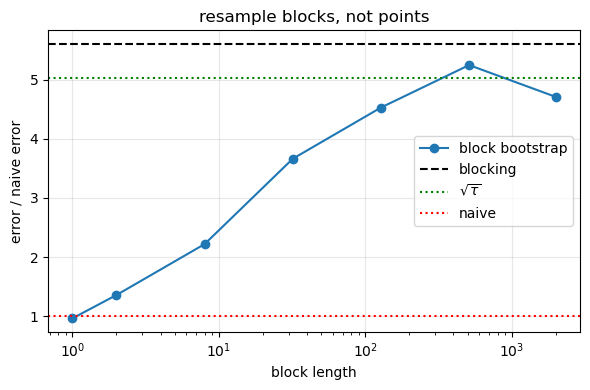

In [22]:
sticky = vo.sample(1.00, 0.40, n_cycles=200000, time_step=0.02,
                   rng=np.random.default_rng(31), keep_samples=True)
e_sticky = sticky["samples"]
tau_s = correlation_time(e_sticky)
naive_s = e_sticky.std(ddof=1)/math.sqrt(len(e_sticky))
print(f"tau = {tau_s:.1f}, so the honest error should be about "
      f"sqrt(tau) = {math.sqrt(tau_s):.1f} x naive\n")

lengths, ratios = [], []
print(f"{'block length':>14s} {'bootstrap error':>18s} {'/ naive':>10s}")
for b in (1, 2, 8, 32, 128, 512, 2000):
    out = vo.block_bootstrap(e_sticky, n_resamples=200, block=b,
                             rng=np.random.default_rng(3))
    lengths.append(b); ratios.append(out["error"]/naive_s)
    print(f"{b:14d} {out['error']:18.8f} {out['error']/naive_s:10.2f}")
_, bs, _ = vo.blocking(e_sticky)
print(f"{'blocking':>14s} {bs:18.8f} {bs/naive_s:10.2f}")

plt.figure(figsize=(6, 4))
plt.semilogx(lengths, ratios, "o-", label="block bootstrap")
plt.axhline(bs/naive_s, ls="--", color="k", label="blocking")
plt.axhline(math.sqrt(tau_s), ls=":", color="g", label=r"$\sqrt{\tau}$")
plt.axhline(1.0, ls=":", color="r", label="naive")
plt.xlabel("block length"); plt.ylabel("error / naive error")
plt.title("resample blocks, not points")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Which to use

- **The mean of a Monte Carlo run** — blocking with Jonsson's rule.  No free
  parameters, no window, conservative.
- **Anything else** — a variance, a ratio, a fitted or extrapolated parameter:
  block bootstrap or block jackknife.  They agree when both apply; the
  jackknife is deterministic and cheaper, the bootstrap gives the whole
  distribution and hence confidence intervals.
- **Bias** — the jackknife, or the bootstrap with a large $B$.
- **Never** $\sigma/\sqrt N$ from a Markov chain, and never a bootstrap that
  resamples single points.  Both are wrong in the same direction and neither
  announces itself.

## 13. The result

In [23]:
mean = series.mean()
print(f"E = {mean:.6f} +/- {error:.6f}\n")
print(f"{'method':<28s} {'energy':>12s} {'error':>10s}")
for label, value in (("Hartree-Fock, 42 orbitals", 3.161921),
                     ("MP2, 42 orbitals", 3.027038),
                     ("CCSD, 42 orbitals", 3.013626),
                     ("VMC, this chapter", mean),
                     ("exact (Taut)", TAUT_ENERGY)):
    print(f"{label:<28s} {value:12.6f} {abs(value-TAUT_ENERGY):10.1e}")
gap = mean - TAUT_ENERGY
naive = series.std(ddof=1)/math.sqrt(len(series))
print(f"\nThe remaining {gap:.6f} is {gap/error:.0f} standard errors wide, and it")
print("is not statistical — it is what two parameters cannot represent.")
print(f"With the naive error one would have quoted {gap/naive:.0f} standard errors")
print("and concluded, wrongly, that something was broken.")

E = 3.000549 +/- 0.000049

method                             energy      error
Hartree-Fock, 42 orbitals        3.161921    1.6e-01
MP2, 42 orbitals                 3.027038    2.7e-02
CCSD, 42 orbitals                3.013626    1.4e-02
VMC, this chapter                3.000549    5.5e-04
exact (Taut)                     3.000000    0.0e+00

The remaining 0.000549 is 11 standard errors wide, and it
is not statistical — it is what two parameters cannot represent.
With the naive error one would have quoted 17 standard errors
and concluded, wrongly, that something was broken.


## What is left

Every result here is bounded above by what two parameters can express, and no
amount of sampling or optimisation changes that.  Two ways out:

- **Diffusion Monte Carlo** removes the dependence on $\Psi_T$ by projecting
  onto the ground state in imaginary time, using the drift and Green's
  function of chapter 13.
- If the trouble is that we cannot *guess* a good enough functional form, the
  alternative is not to guess: parametrise $\Psi_T$ by a neural network and
  let the gradient and the stochastic-reconfiguration step do the rest.